# Teach RNN Motion

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
# System imports
from pathlib import Path
import sys
from datetime import date
from collections import defaultdict
import json

# Plotting imports
import matplotlib.pyplot as plt
import seaborn as sns

# Scientific imports
import numpy as np

# NN imports
import torch
import torch.nn as nn
import torch.nn.functional as F
import neurogym as ngym

# For import from src folder in linux
ROOT = Path().cwd().parent
SRC_PATH = ROOT / 'src'
sys.path.append(str(ROOT))
sys.path.append(str(SRC_PATH))

# Custom imports
from src.environments import TAMTask, MotionTask, load_motion_from_image, load_tam_from_image
from src.train_test_utils import plot_dataset, plot_training_curves
# from src.networks import TAMNet, CNNNet
from src.networks import TAMNet
from src.utils import load_params

In [3]:
# Set the seaborn theme
sns.set_theme(
    font_scale=1.8,
    style='white',
    context='poster',
    # font='Segoe UI',
)

## 0. Basic settings


In [4]:
%matplotlib inline

In [5]:
# Set directories
# Figures
today = date.today().strftime('%m-%d-%Y')
FIG_DIR = ROOT / 'figures' / today
FIG_DIR.mkdir(parents=True, exist_ok=True)

# Network
MODEL_DIR = ROOT / 'data' / 'models'
MODEL_DIR.mkdir(parents=True, exist_ok=True)

# Stimuli
STIM_DIR = ROOT / 'data' / 'stimuli' / "TAM_basic"

In [66]:
# Load parameters
params = load_params(str(ROOT / 'parameters.json'))
exp_params = params["EXPERIMENT"]
env_params = params['TASK']
training_envs = defaultdict()
training_datasets = defaultdict()
motion_dirs = ["horizontal"]
box_shapes = ["square", "circle", "triangle"]

img_size = 100
batch_size = 64
seq_len = 100

In [67]:
# WORKED
# img_size = 64
# batch_size = 16
# seq_len = 100

# Higher batch size generalizes to other shapes
# Higher seq_len generalizes to outlines

In [68]:
# Create environments and datasets
for md in motion_dirs:
    for bs in box_shapes:
        print(md, bs)
        stimuli = load_tam_from_image(img_size, stim_path=STIM_DIR)
        env = TAMTask(
            box_shape=bs,
            stim_type="tam",
            stimuli=stimuli,
            stim_ori=md,
            dt=env_params["dt"],
            # sigma=env_params["sigma"],
            sigma=0.01,
            img_size=img_size
        )
        env.reset(no_step=True)

        # Generate dataset object
        dataset = ngym.Dataset(
            env,
            batch_size=batch_size,
            seq_len=seq_len
        )

        # Add dataset to dictionary
        training_envs[f'{bs}-{md}'] = env
        training_datasets[f'{bs}-{md}'] = dataset

horizontal square
horizontal circle
horizontal triangle


In [69]:
# Create environments and datasets
tam_test_datasets = defaultdict()
motion_test_datasets = defaultdict()
tam_types = ["tam", "outline"]
motion_types = ["cnt", "track"]

for bs in box_shapes:
    for tt in tam_types:
        for md in motion_dirs:
            print(bs, tt, md)
            if tt == "tam":
                _path = STIM_DIR
            else:
                _path = STIM_DIR.parent / "TAM_outline"

            stimuli = load_tam_from_image(img_size, stim_type=tt, stim_path=_path)
            env = TAMTask(
                box_shape=bs,
                stimuli=stimuli,
                stim_type=tt,
                stim_ori=md,
                dt=env_params["dt"],
                sigma=0.01,
                img_size=img_size
            )
            env.reset(no_step=True)

            # Generate dataset object
            dataset = ngym.Dataset(
                env,
                batch_size=batch_size,
                seq_len=seq_len
            )

            # Add dataset to dictionary
            tam_test_datasets[f'{bs}-{tt}-{md}'] = env
            tam_test_datasets[f'{bs}-{tt}-{md}'] = dataset

# for bs in box_shapes:
#     for mt in motion_types:
#         for md in motion_dirs:
#
#             print(bs, mt, md)
#
#             stimuli = load_motion_from_image(img_size, stim_path=STIM_DIR.parent / "motion_task")
#             env = MotionTask(
#                 dt=env_params["dt"],
#                 box_shape=bs,
#                 motion_type=mt,
#                 stim_ori=md,
#                 stimuli=stimuli,
#                 sigma=0,
#                 img_size=img_size
#             )
#             env.reset(no_step=True)
#
#             # Generate dataset object
#             dataset = ngym.Dataset(
#                 env,
#                 batch_size=batch_size,
#                 seq_len=seq_len
#             )
#
#             # Add dataset to dictionary
#             motion_test_datasets[f'{bs}-{mt}-{md}'] = env
#             motion_test_datasets[f'{bs}-{mt}-{md}'] = dataset

square tam horizontal
square outline horizontal
circle tam horizontal
circle outline horizontal
triangle tam horizontal
triangle outline horizontal


In [70]:
# Look at the shapes of the datasets
inputs, target = training_datasets["square-horizontal"]()
print('Input has shape (SeqLen, Batch, C, W, H) =', inputs.shape)
print('Target has shape (SeqLen, Batch) =', target.shape)
print('Targets in the first sequence:')
print(target[:, 0])

Input has shape (SeqLen, Batch, C, W, H) = (100, 64, 100, 100)
Target has shape (SeqLen, Batch) = (100, 64)
Targets in the first sequence:
[0 0 0 3 3 3 3 3 3 0 0 0 2 2 2 2 2 2 0 0 0 1 1 1 1 1 1 0 0 0 3 3 3 3 3 3 0
 0 0 3 3 3 3 3 3 0 0 0 1 1 1 1 1 1 0 0 0 3 3 3 3 3 3 0 0 0 1 1 1 1 1 1 0 0
 0 2 2 2 2 2 2 0 0 0 2 2 2 2 2 2 0 0 0 1 1 1 1 1 1 0]


In [71]:
cnn_features = np.zeros_like(inputs)
for seq in range(inputs.shape[0]):
    for batch in range(inputs.shape[1]):
        img = torch.from_numpy(inputs[seq, batch].reshape(1, 1, 100, 100)).type(torch.float).to(device)
        print(img.shape)

        _, output = CNN(img)
        output = output.detach().cpu().numpy()

torch.Size([1, 1, 100, 100])
torch.Size([1, 1, 100, 100])
torch.Size([1, 1, 100, 100])
torch.Size([1, 1, 100, 100])
torch.Size([1, 1, 100, 100])
torch.Size([1, 1, 100, 100])
torch.Size([1, 1, 100, 100])
torch.Size([1, 1, 100, 100])
torch.Size([1, 1, 100, 100])
torch.Size([1, 1, 100, 100])
torch.Size([1, 1, 100, 100])
torch.Size([1, 1, 100, 100])
torch.Size([1, 1, 100, 100])
torch.Size([1, 1, 100, 100])
torch.Size([1, 1, 100, 100])
torch.Size([1, 1, 100, 100])
torch.Size([1, 1, 100, 100])
torch.Size([1, 1, 100, 100])
torch.Size([1, 1, 100, 100])
torch.Size([1, 1, 100, 100])
torch.Size([1, 1, 100, 100])
torch.Size([1, 1, 100, 100])
torch.Size([1, 1, 100, 100])
torch.Size([1, 1, 100, 100])
torch.Size([1, 1, 100, 100])
torch.Size([1, 1, 100, 100])
torch.Size([1, 1, 100, 100])
torch.Size([1, 1, 100, 100])
torch.Size([1, 1, 100, 100])
torch.Size([1, 1, 100, 100])
torch.Size([1, 1, 100, 100])
torch.Size([1, 1, 100, 100])
torch.Size([1, 1, 100, 100])
torch.Size([1, 1, 100, 100])
torch.Size([1,

In [102]:
# Load parameters
net_params = params['NETWORK']
device = torch.device(net_params["device"])
# device = torch.device('cpu')

# Create network to train on the normal stimuli
net = TAMNet(
    dataset=training_datasets["square-horizontal"],
    hidden_size=2048,
    output_size=training_datasets["square-horizontal"].env.action_space.n,
    learning_rate=0.0005,
    device=device
)

In [103]:
class CNNNet(nn.Module):
    """
    Convolutional network model.

    """
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 32, 3, 1)
        self.conv2 = nn.Conv2d(32, 64, 3, 1)
        self.conv3 = nn.Conv2d(64, 128, 5, 1)
        self.dropout1 = nn.Dropout(0.25)
        self.dropout2 = nn.Dropout(0.5)
        self.fc1 = nn.Linear(10368, 4096)
        self.fc2 = nn.Linear(4096, 1024)
        self.fc3 = nn.Linear(1024, 64)
        self.fc4 = nn.Linear(64, 9)

    def forward(self, inputs):
        h_new = self.conv1(inputs)
        h_new = F.relu(h_new)
        h_new = F.max_pool2d(h_new, 2)
        h_new = self.conv2(h_new)
        h_new = F.relu(h_new)
        h_new = F.max_pool2d(h_new, 2)
        h_new = self.conv3(h_new)
        h_new = F.relu(h_new)
        h_new = F.max_pool2d(h_new, 2)
        h_new = self.dropout1(h_new)
        h_new = torch.flatten(h_new, 1)
        h_new = self.fc1(h_new)
        h_new = F.relu(h_new)
        h_new = self.dropout2(h_new)
        h_new = self.fc2(h_new)
        h_new = F.relu(h_new)
        fc3_features = self.fc3(h_new)
        h_new = F.relu(fc3_features)
        output = self.fc4(h_new)

        return output, fc3_features

In [104]:
# CNN
CNN = CNNNet().to(device)
CNN.load_state_dict(torch.load(MODEL_DIR / 'cnn_model_64.pt'))

<All keys matched successfully>

In [105]:
# Train network
train_loss, train_acc = net.train_rnn(
    datasets=[
        training_datasets["square-horizontal"],
        # training_datasets["triangle-horizontal"],
        # training_datasets["circle-horizontal"],
    ],
    # n_epochs=net_params["n_epochs"]
    n_epochs=1000,
    cnn=CNN
)

Training started...
Step 100, Loss 16.3158, Time 813.9s
Step 200, Loss 0.2016, Time 1631.1s
Step 300, Loss 0.2169, Time 2448.7s
Step 400, Loss 0.2194, Time 3268.1s
Step 500, Loss 0.3766, Time 4090.6s
Step 600, Loss 0.1918, Time 4909.7s
Step 700, Loss 0.0815, Time 5727.8s
Step 800, Loss 0.0665, Time 6549.8s
Step 900, Loss 0.4273, Time 7370.6s
Step 1000, Loss 0.1021, Time 8190.0s


In [107]:
trained_rnn = net.RNN

In [108]:
# save network
torch.save(trained_rnn.state_dict(), MODEL_DIR / f'CNN_horiz_tam_2048.pt')

In [109]:
# trained_rnn.load_state_dict(torch.load(MODEL_DIR / f'CNN_horiz_tam.pt'))

In [110]:
trained_rnn.eval()

RNNNet(
  (rnn): CTRNN(
    (input2h): Linear(in_features=64, out_features=2048, bias=True)
    (h2h): Linear(in_features=2048, out_features=2048, bias=True)
  )
  (fc): Linear(in_features=2048, out_features=6, bias=True)
)

In [111]:
# Test on other environments
test_accuracies = defaultdict()
test_activities = defaultdict()
infos = defaultdict()
for et, dataset in tam_test_datasets.items():
    info, activity, test_acc = net.test_rnn(100, dataset, CNN)
    # infos[et] = info
    # test_accuracies[et] = test_acc
    # test_activities[et] = activity
    print(f'Accuracy on {et} = {test_acc}')

Accuracy on square-tam-horizontal = 0.99
Accuracy on square-outline-horizontal = 0.43
Accuracy on circle-tam-horizontal = 0.39
Accuracy on circle-outline-horizontal = 0.28
Accuracy on triangle-tam-horizontal = 0.69
Accuracy on triangle-outline-horizontal = 0.27


In [130]:
infos["square-outline-horizontal"]

array([defaultdict(None, {'ground_truth': 3, 'choice': 3, 'correct': True}),
       defaultdict(None, {'ground_truth': 1, 'choice': 1, 'correct': True}),
       defaultdict(None, {'ground_truth': 3, 'choice': 3, 'correct': True}),
       defaultdict(None, {'ground_truth': 1, 'choice': 1, 'correct': True}),
       defaultdict(None, {'ground_truth': 2, 'choice': 1, 'correct': False}),
       defaultdict(None, {'ground_truth': 1, 'choice': 1, 'correct': True}),
       defaultdict(None, {'ground_truth': 2, 'choice': 3, 'correct': False}),
       defaultdict(None, {'ground_truth': 2, 'choice': 3, 'correct': False}),
       defaultdict(None, {'ground_truth': 1, 'choice': 1, 'correct': True}),
       defaultdict(None, {'ground_truth': 2, 'choice': 1, 'correct': False}),
       defaultdict(None, {'ground_truth': 3, 'choice': 3, 'correct': True}),
       defaultdict(None, {'ground_truth': 2, 'choice': 3, 'correct': False}),
       defaultdict(None, {'ground_truth': 2, 'choice': 3, 'correct': Fa

In [14]:
for et, dataset in motion_test_datasets.items():
    _, activity, test_acc = net.test_rnn(100, dataset)
    # test_accuracies[et] = test_acc
    # test_activities[et] = activity
    print(f'Accuracy on {et} = {test_acc}')

Accuracy on square-cnt-horizontal = 0.09
Accuracy on square-track-horizontal = 0.0


KeyboardInterrupt: 

## Visualize datasets

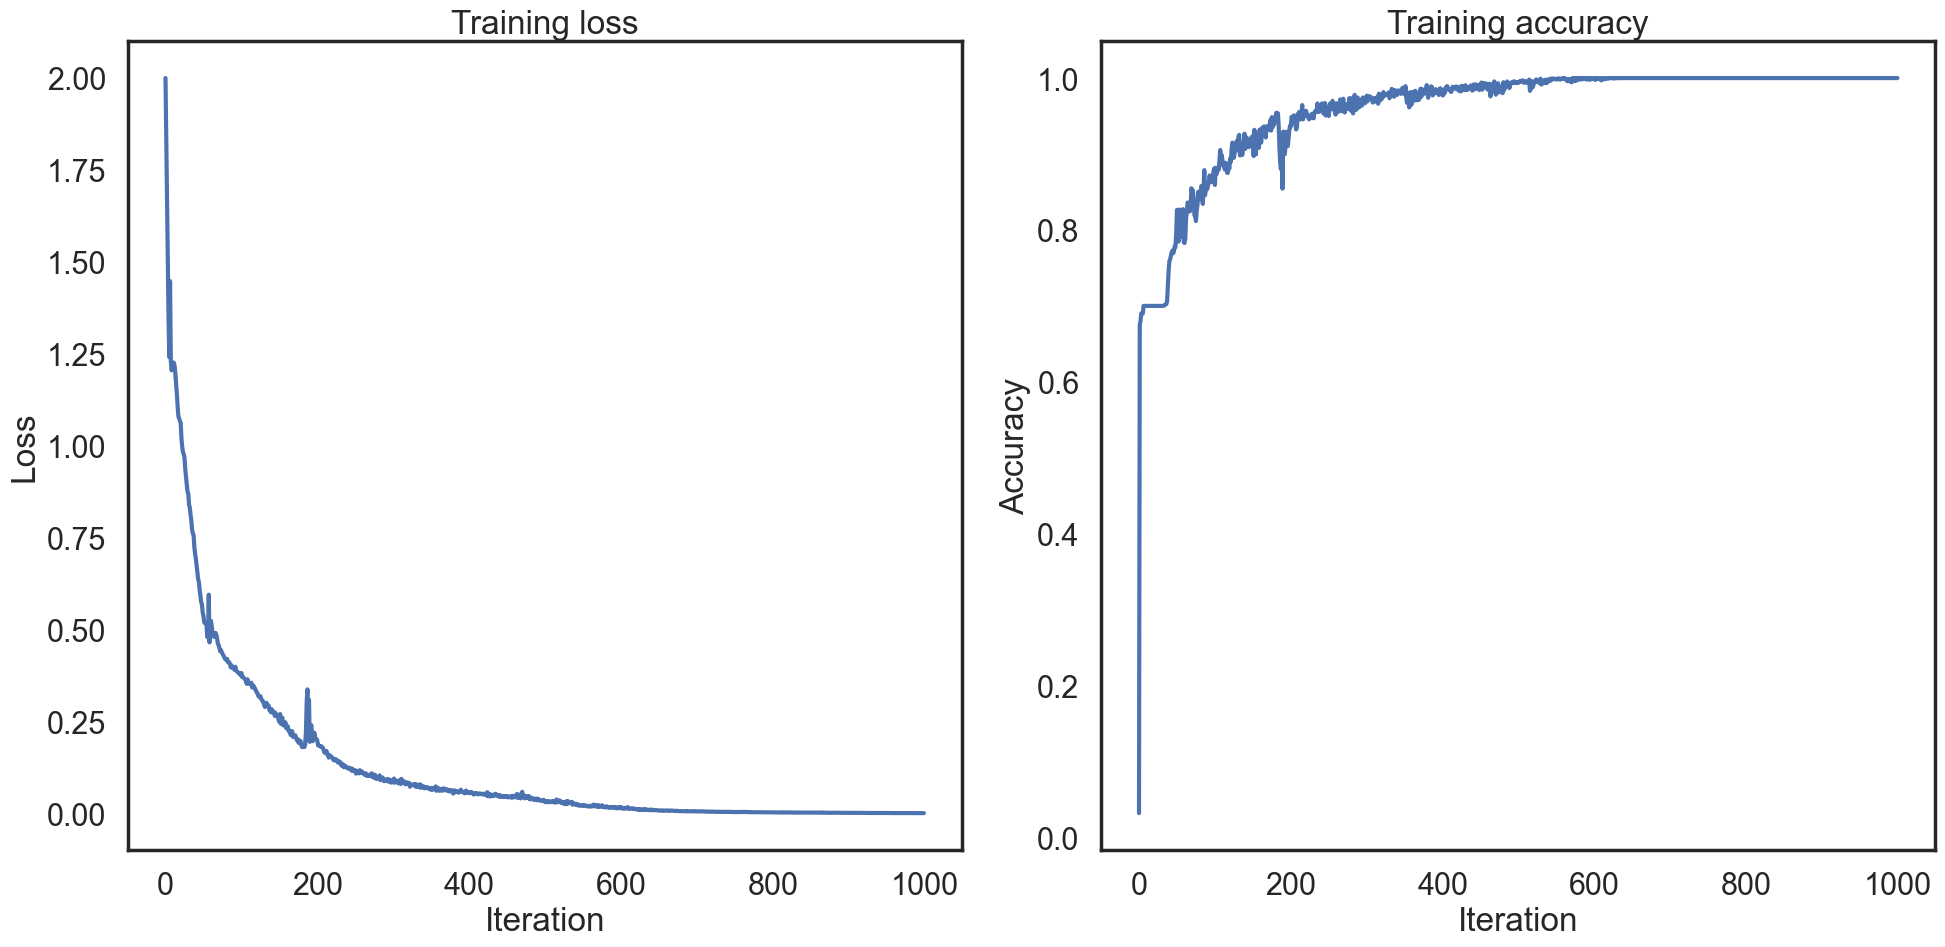

In [47]:
# Plot learning curve
fig, ax = plt.subplots(1, 2, figsize=(20, 10))
ax[0].plot(train_loss[:500])
ax[0].set_xlabel('Iteration')
ax[0].set_ylabel('Loss')
ax[0].set_title('Training loss')
ax[1].plot(train_acc[:500])
ax[1].set_xlabel('Iteration')
ax[1].set_ylabel('Accuracy')
ax[1].set_title('Training accuracy')
plt.tight_layout()
plt.savefig(FIG_DIR / 'TAM_TAM_training_curve.png')
plt.show()

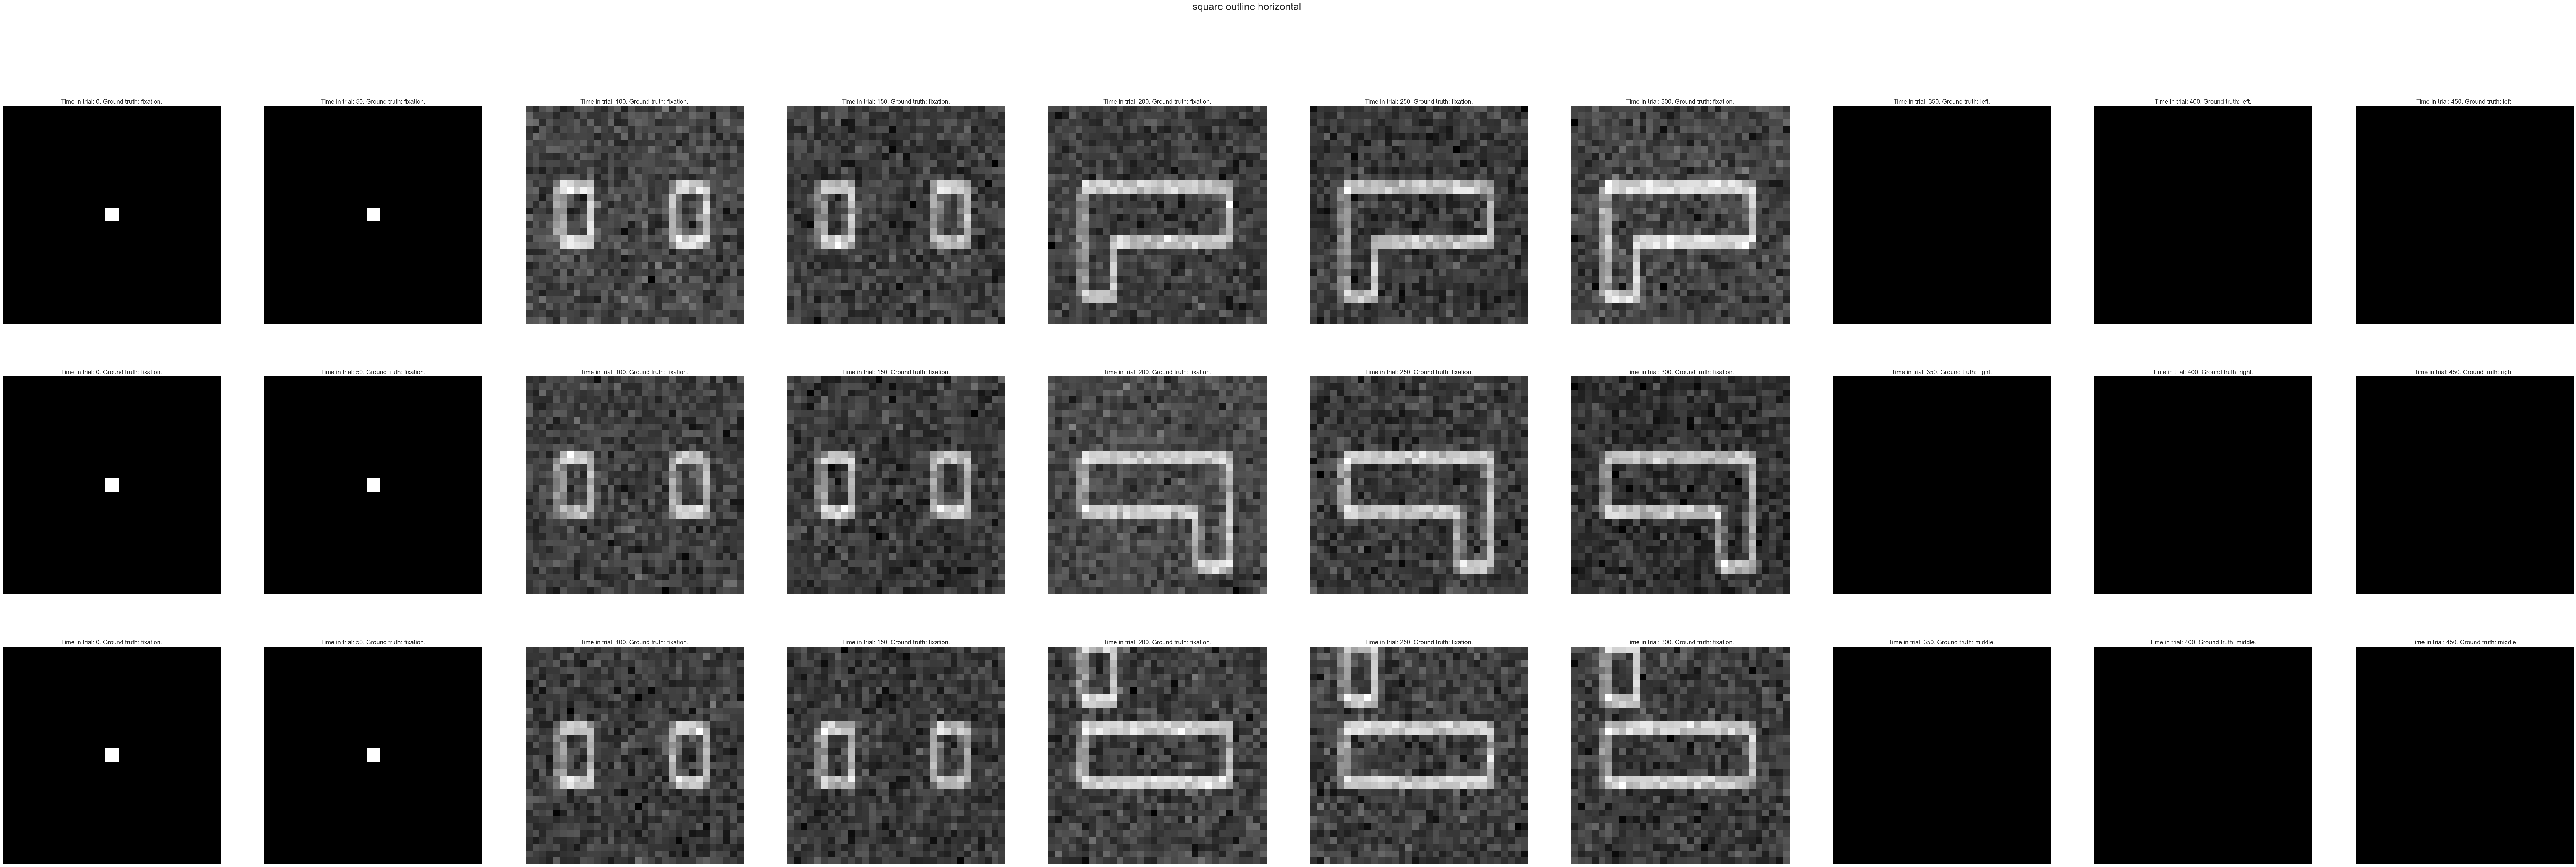

In [84]:
plot_dataset(n_trials=3, dataset=tam_test_datasets["square-outline-horizontal"])

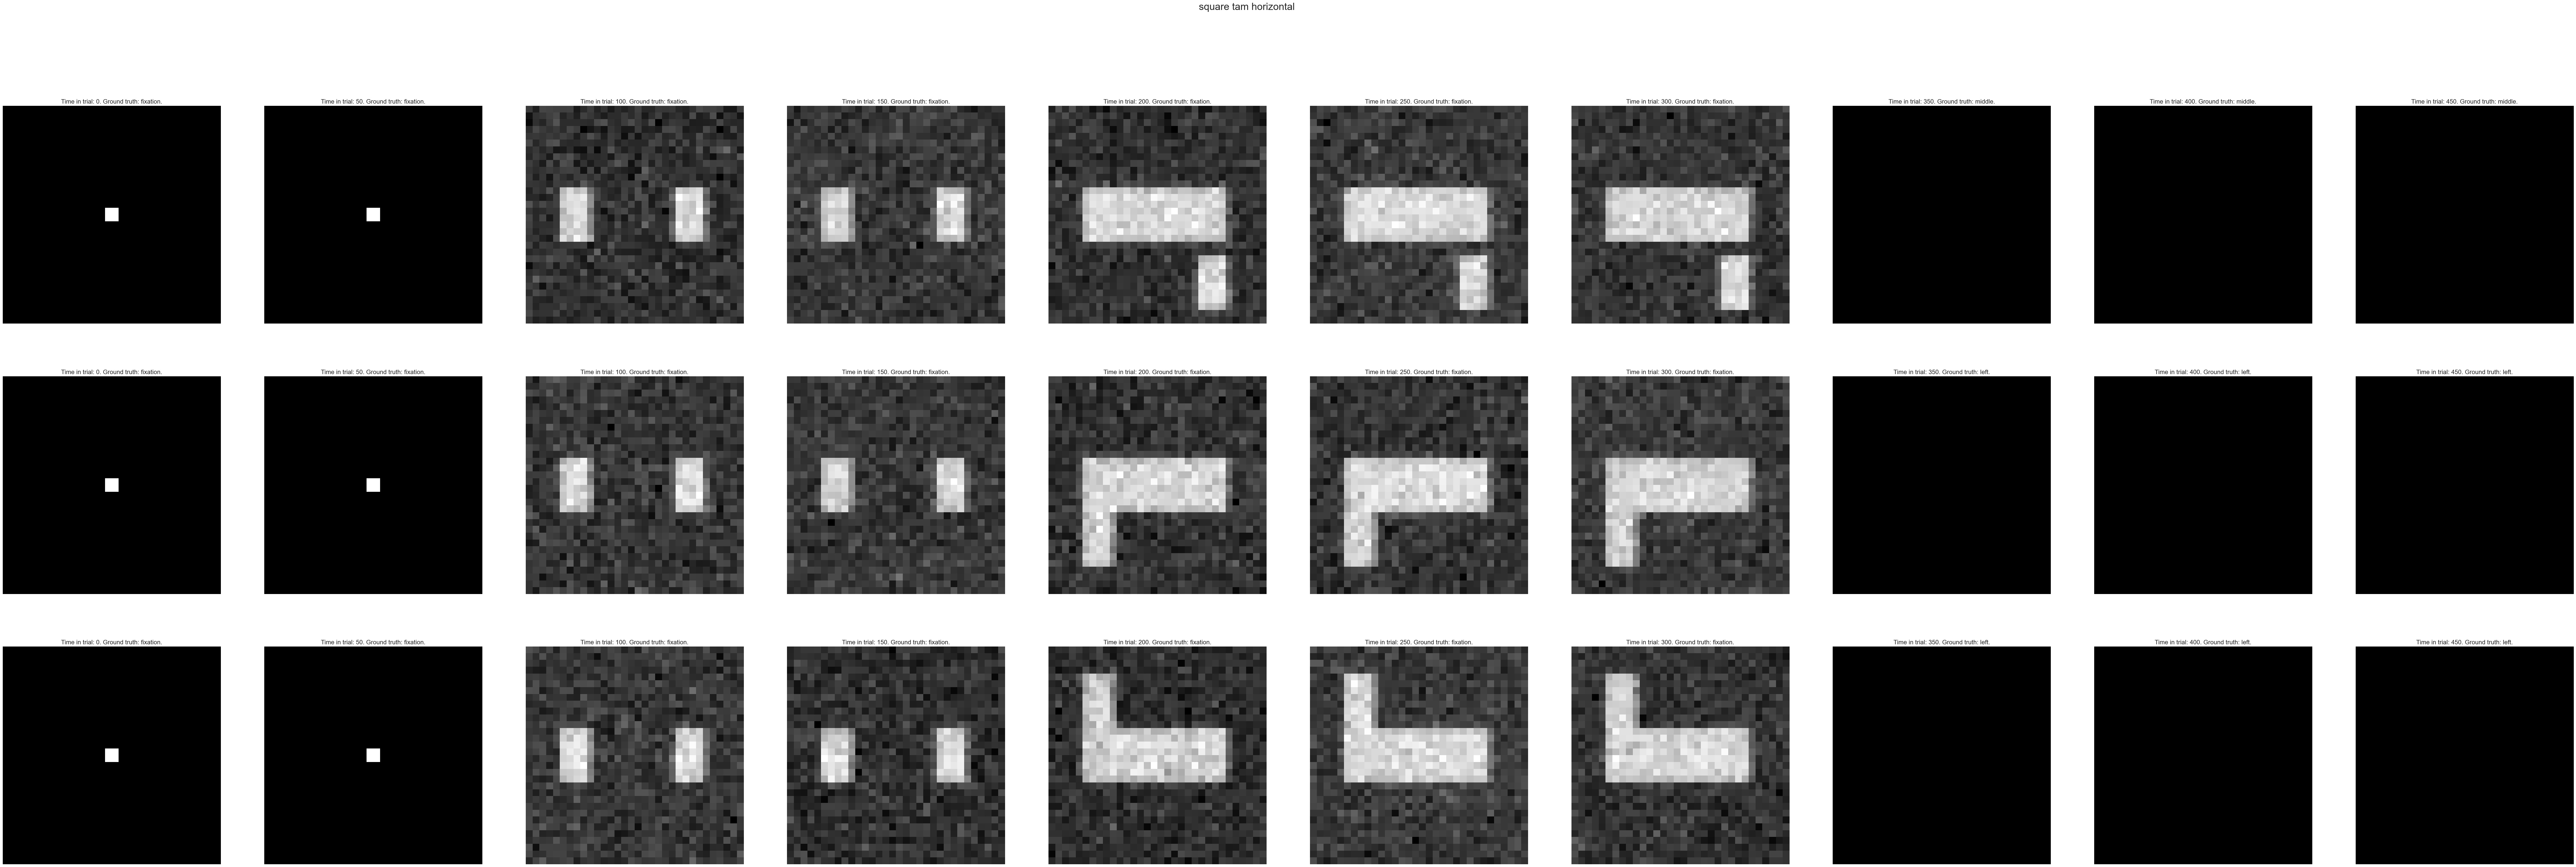

In [85]:
plot_dataset(n_trials=3, dataset=tam_test_datasets["square-tam-horizontal"])

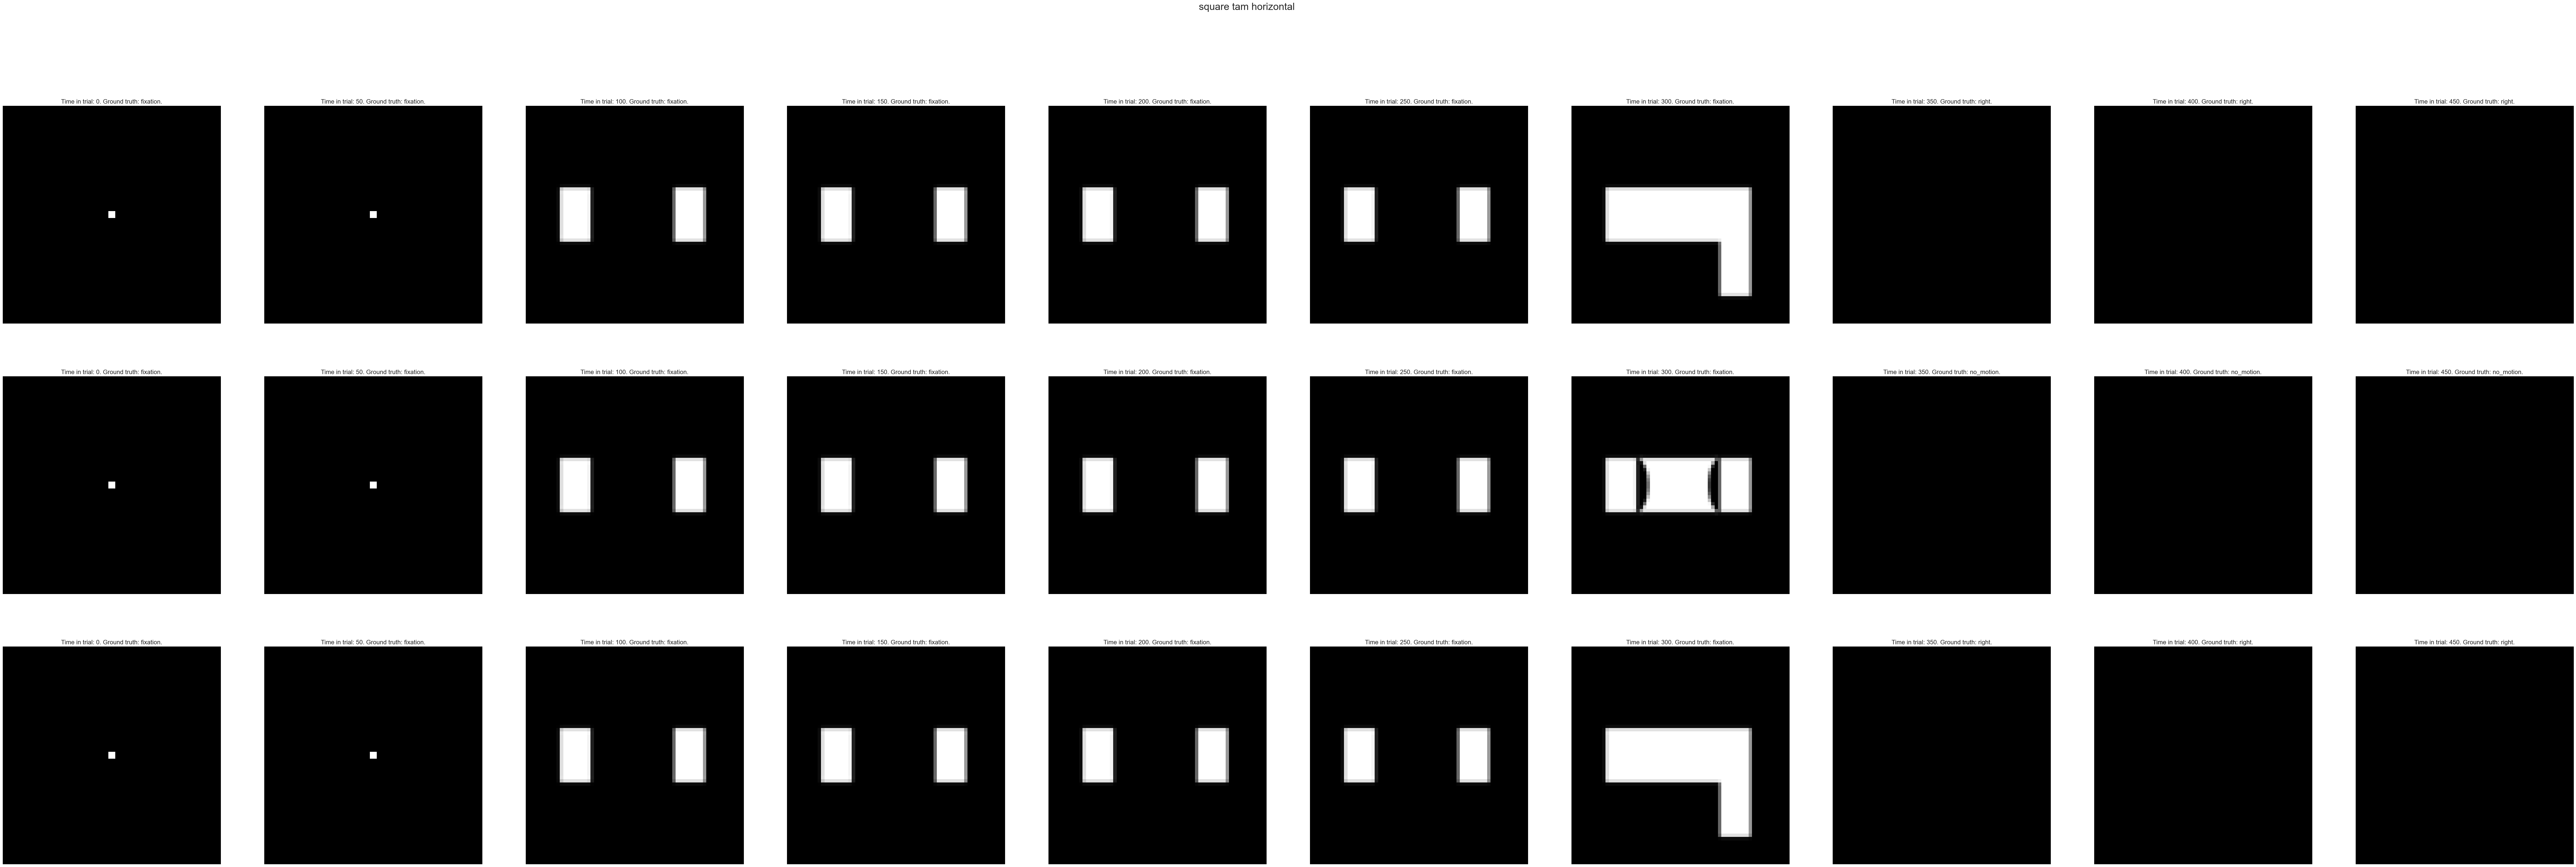

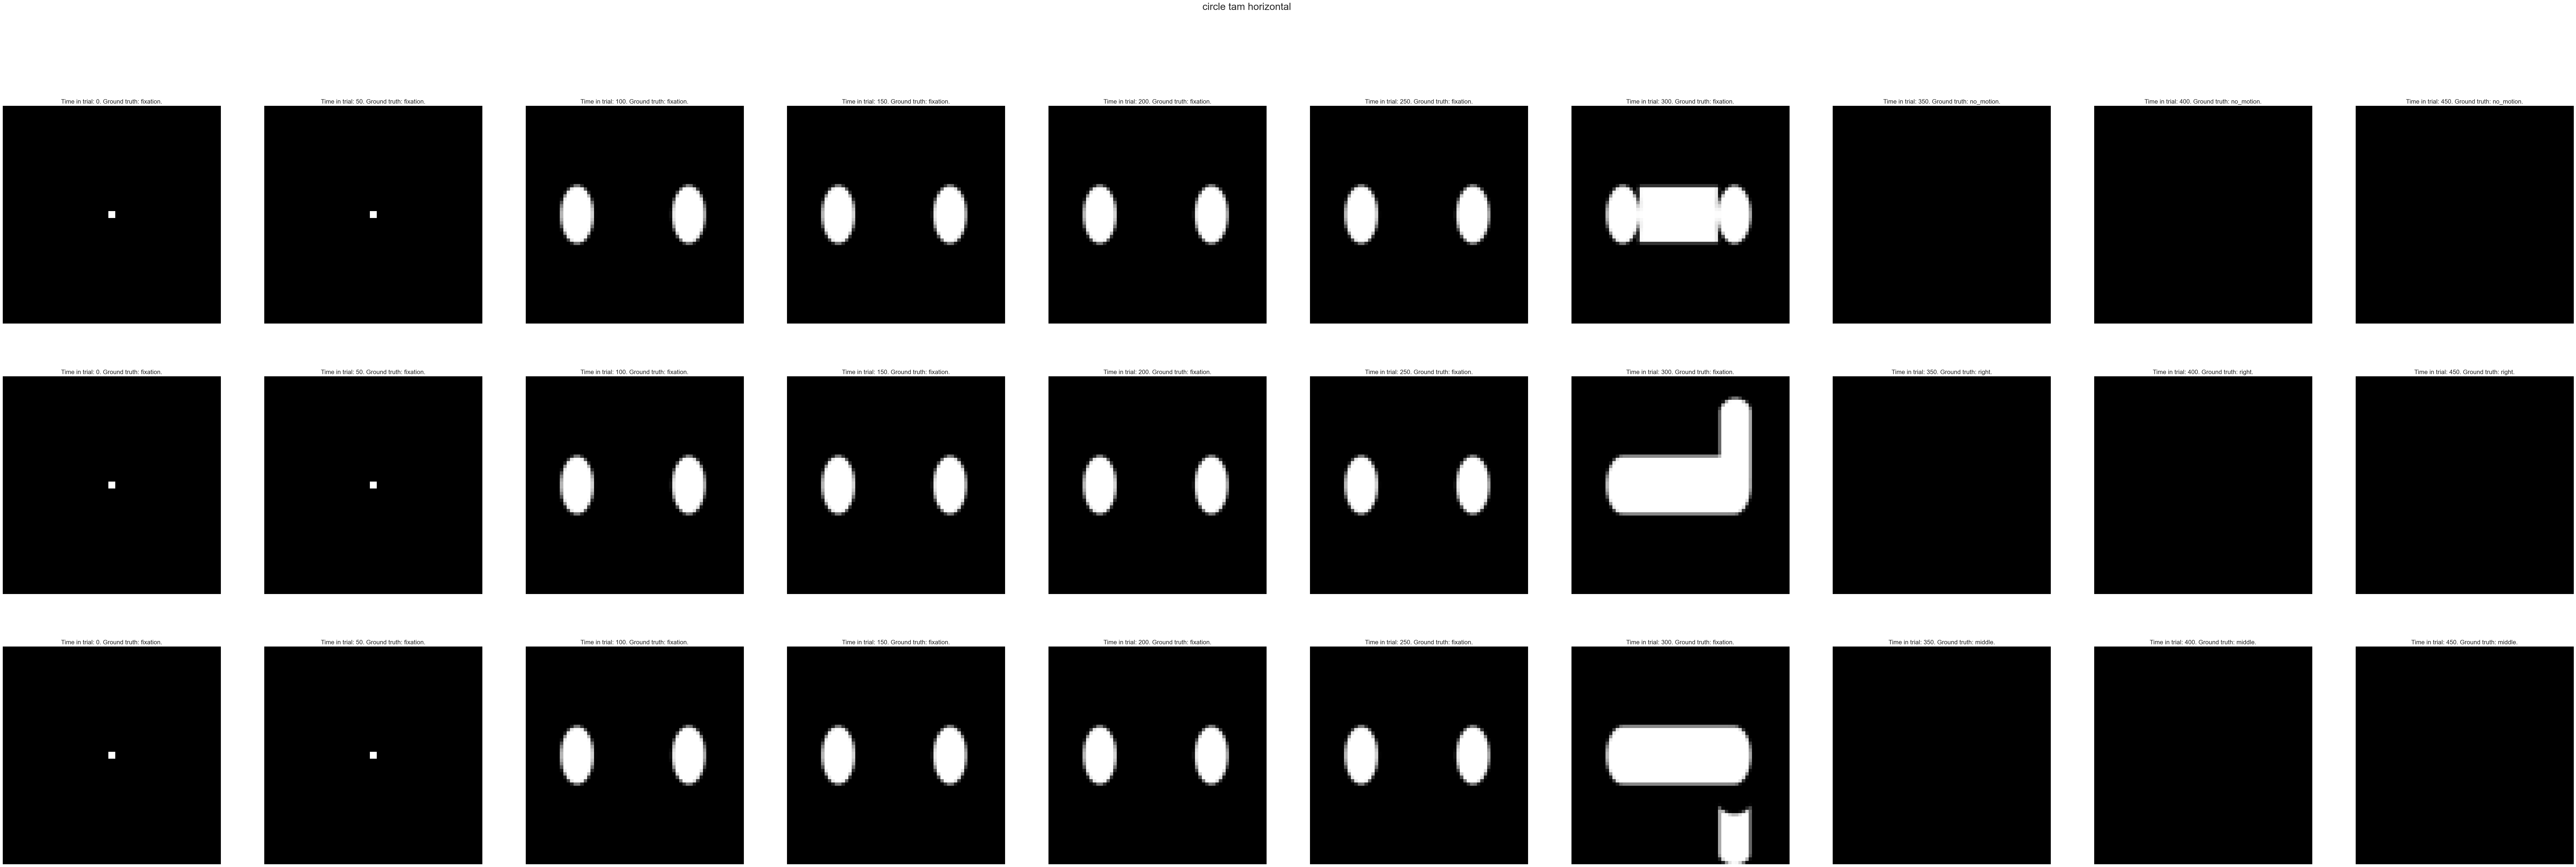

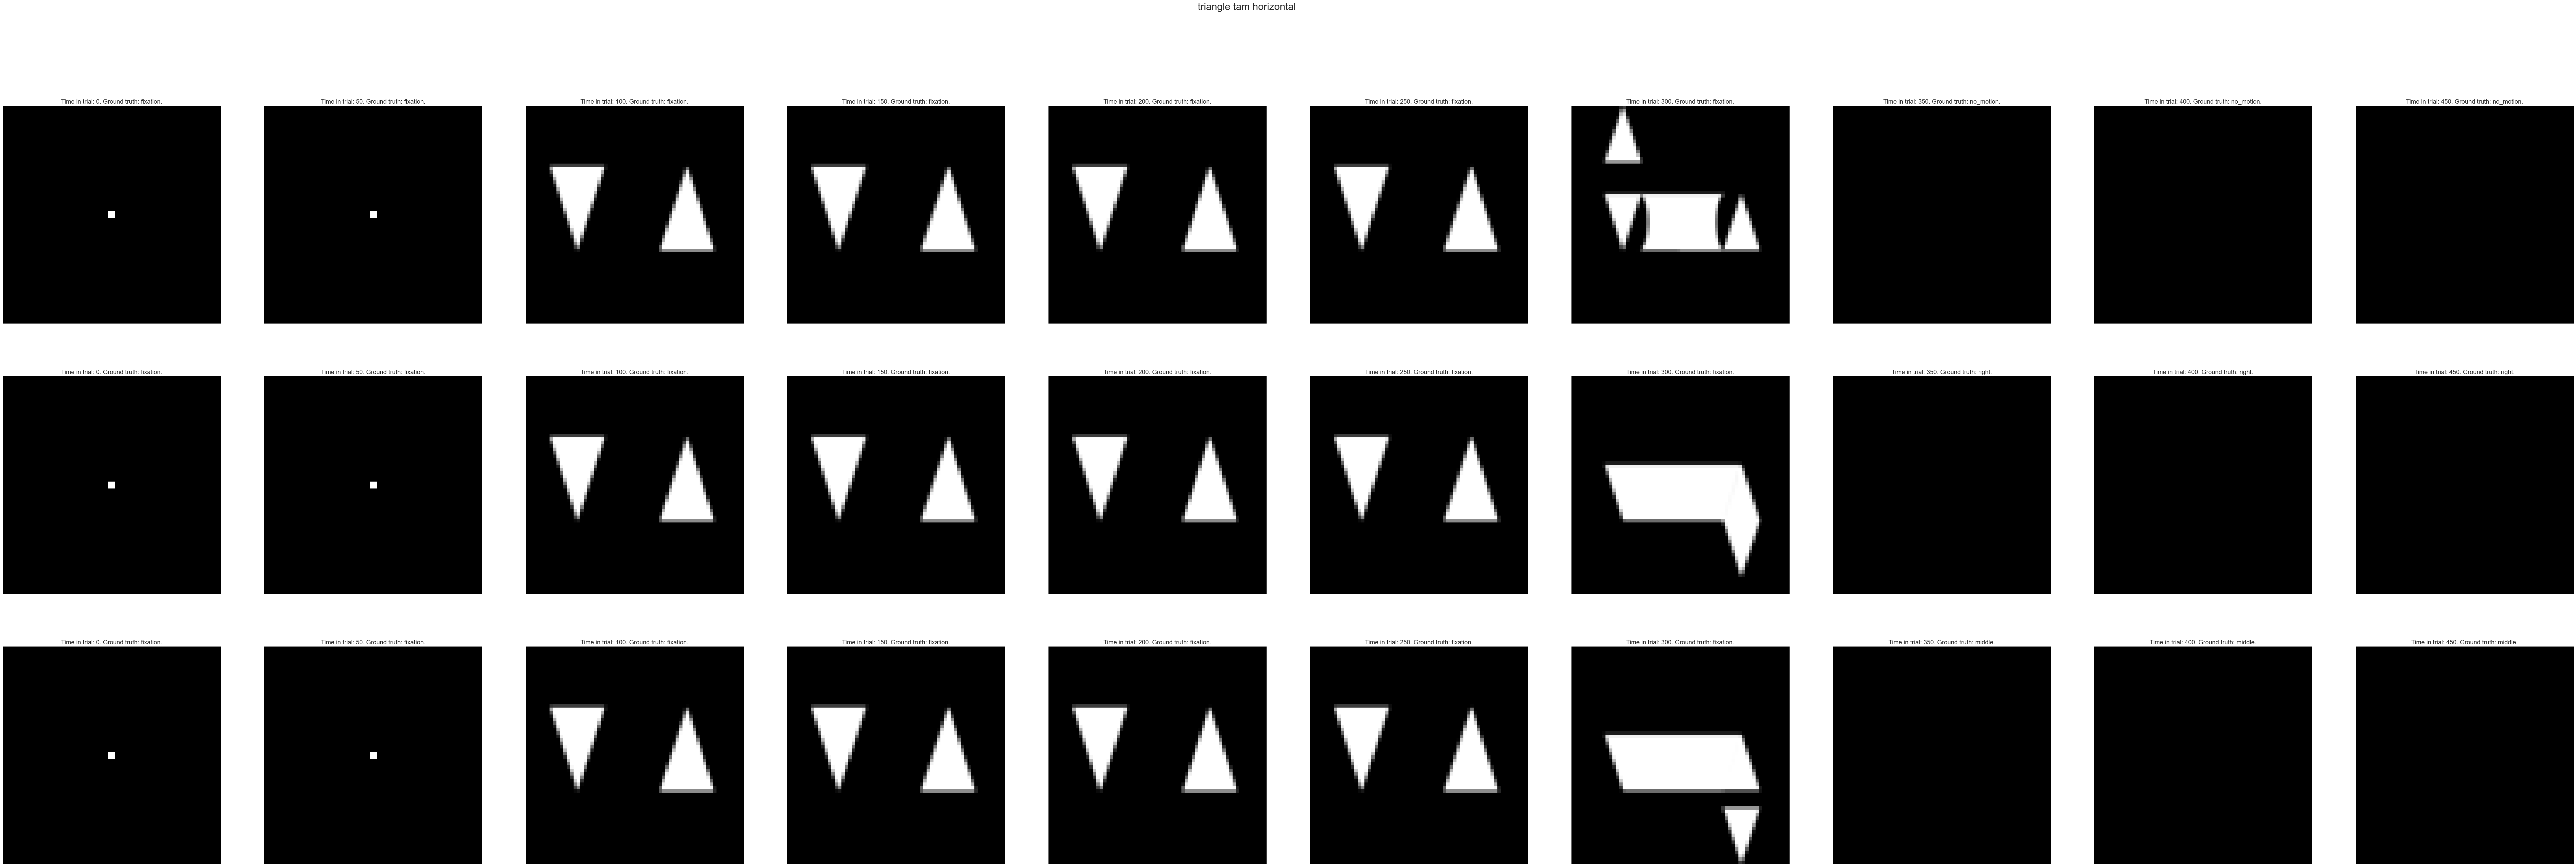

In [15]:
for dataset in training_datasets.values():
    plot_dataset(n_trials=3, dataset=dataset, save_dir=FIG_DIR)

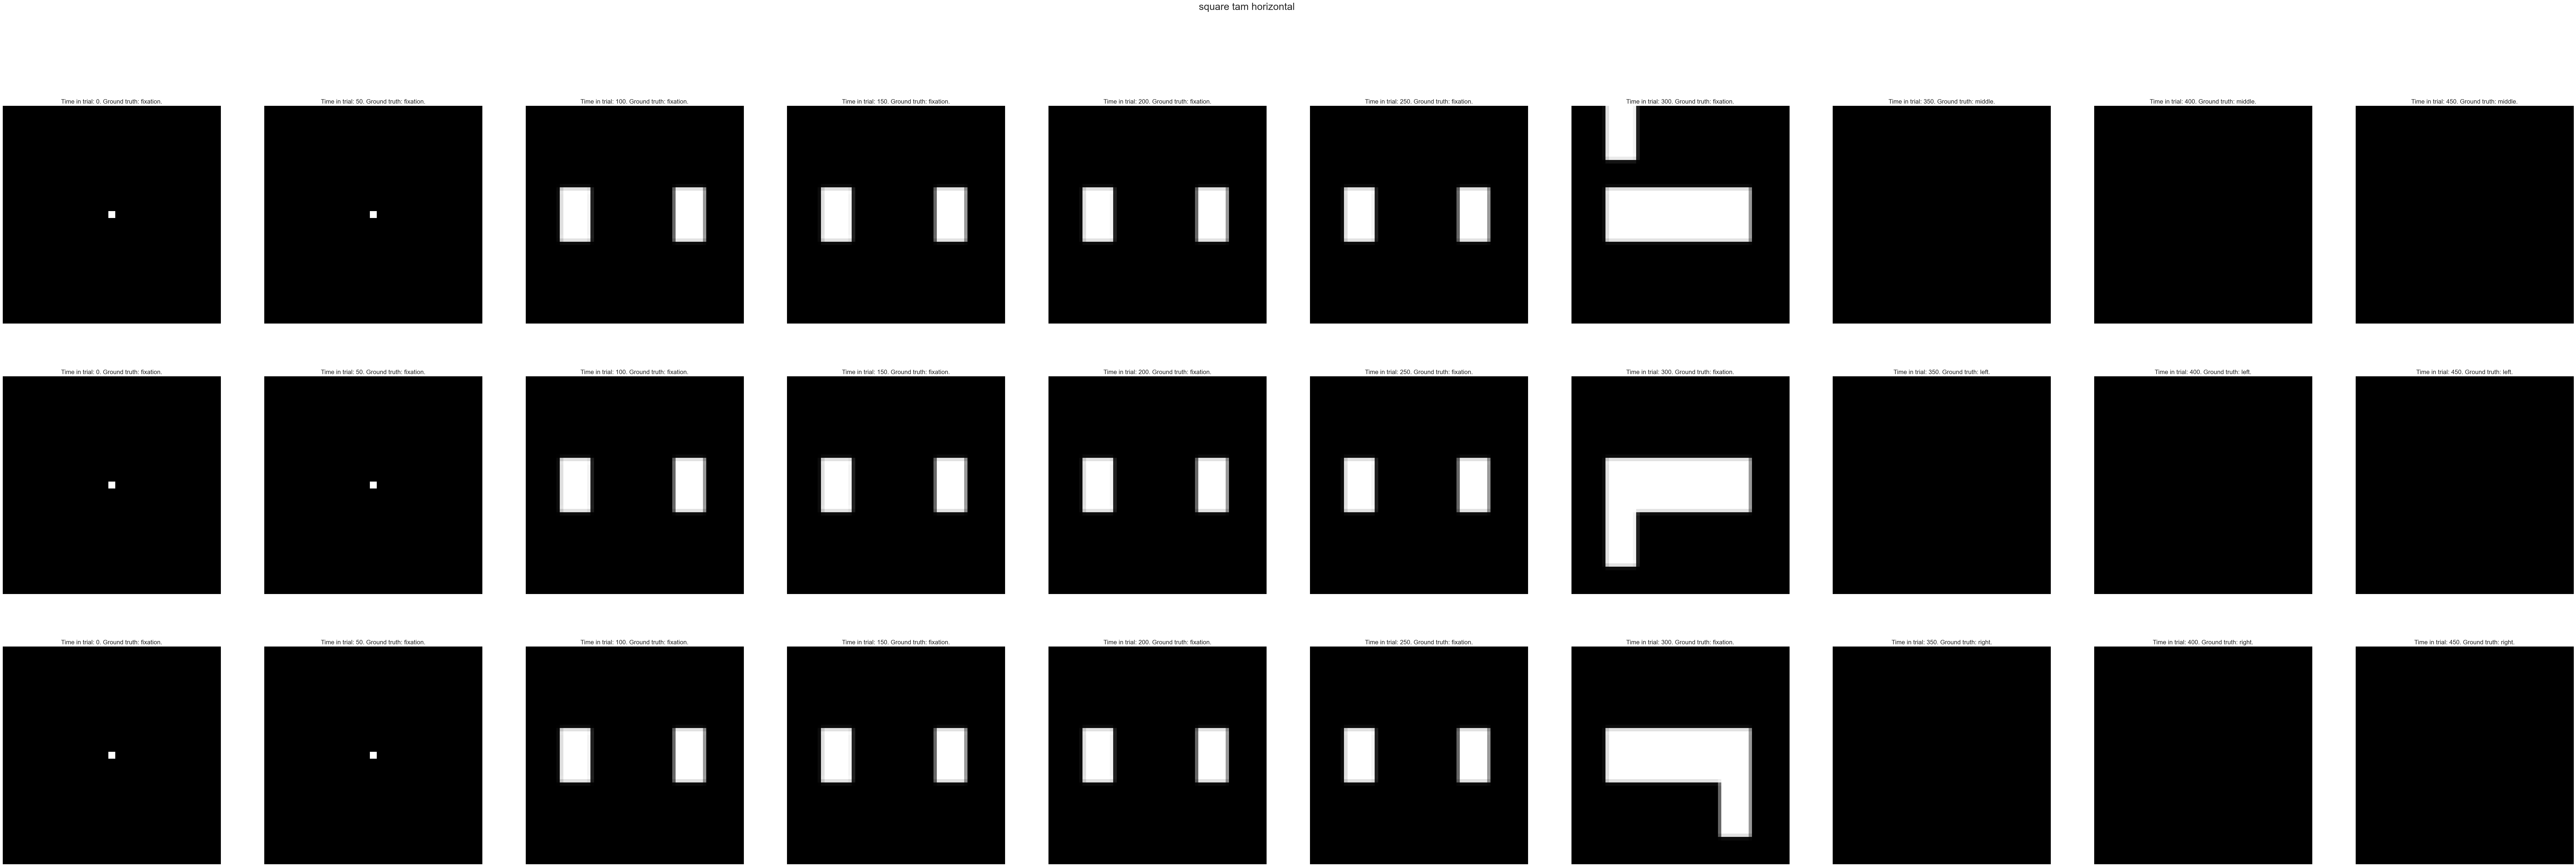

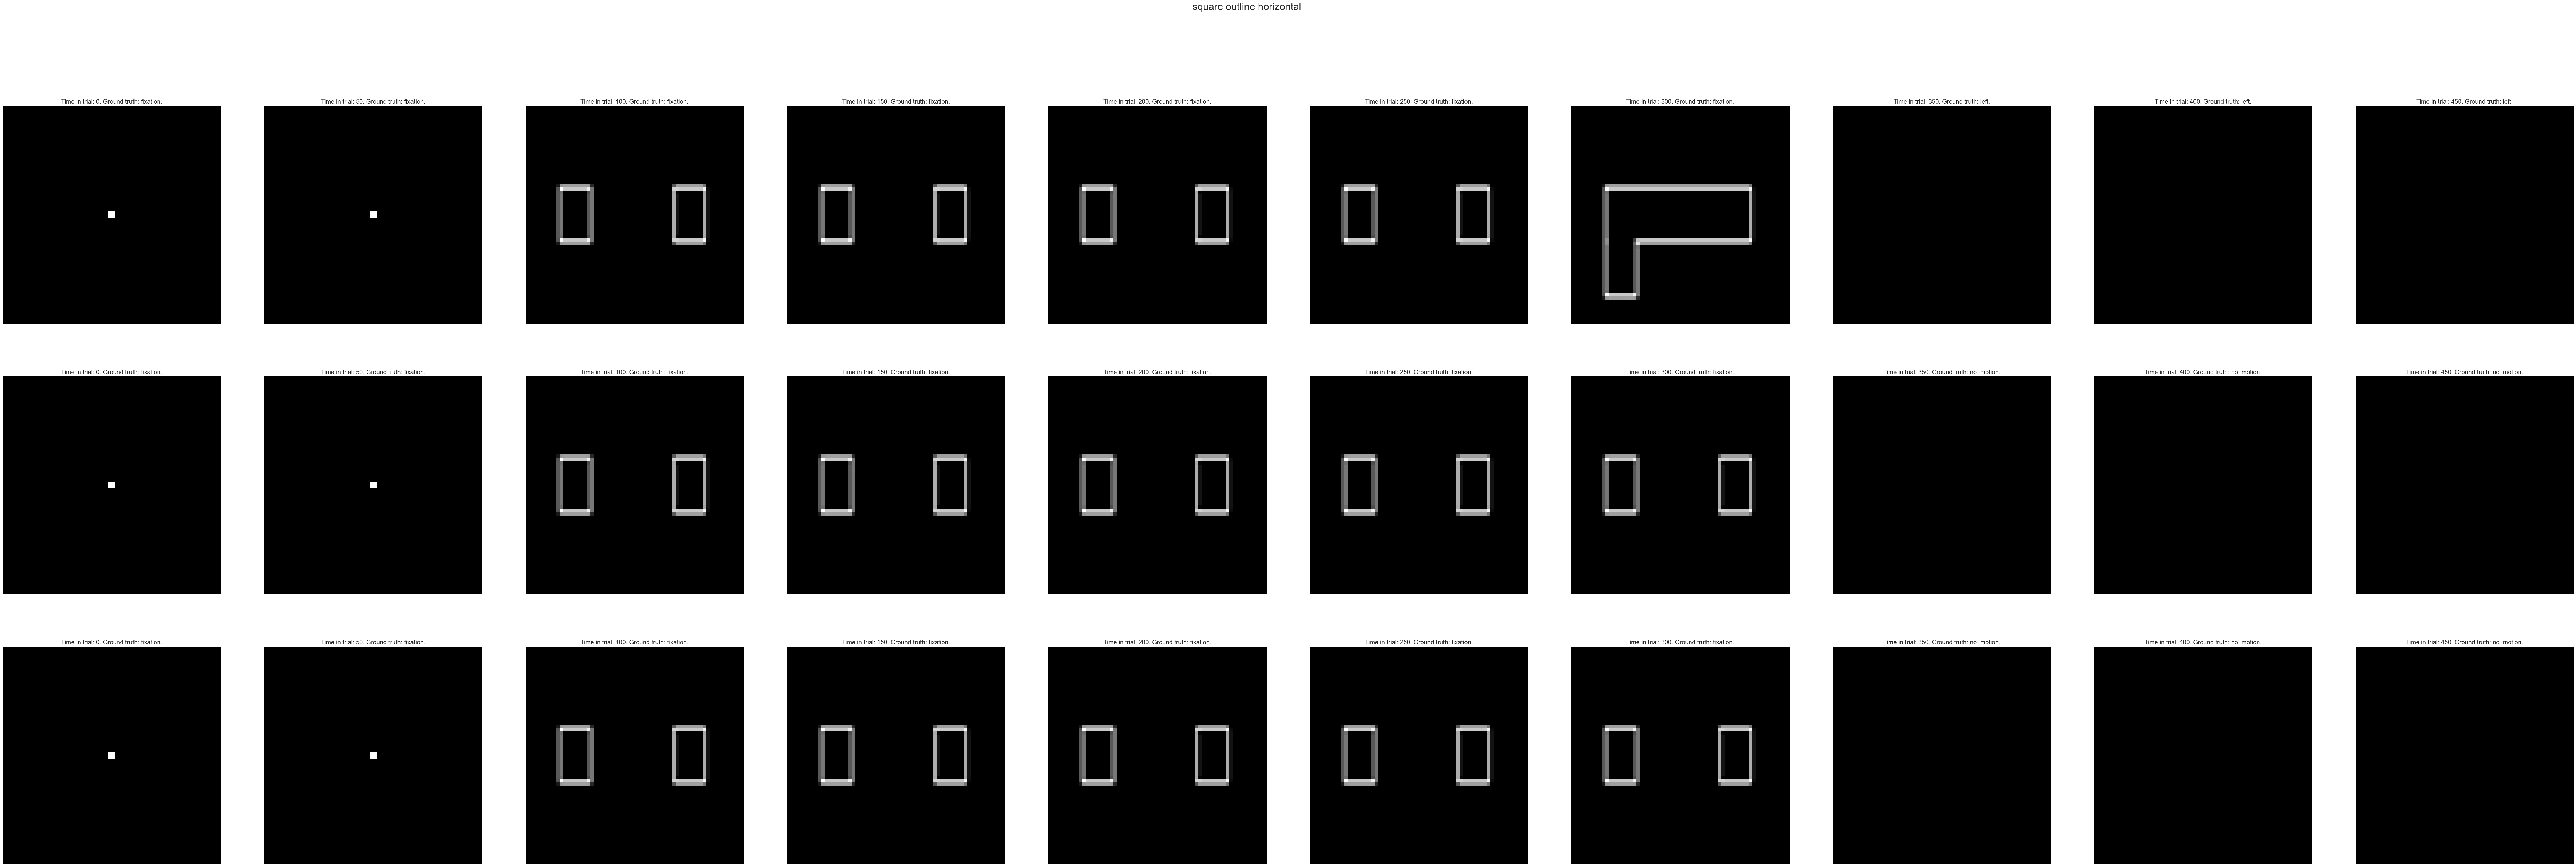

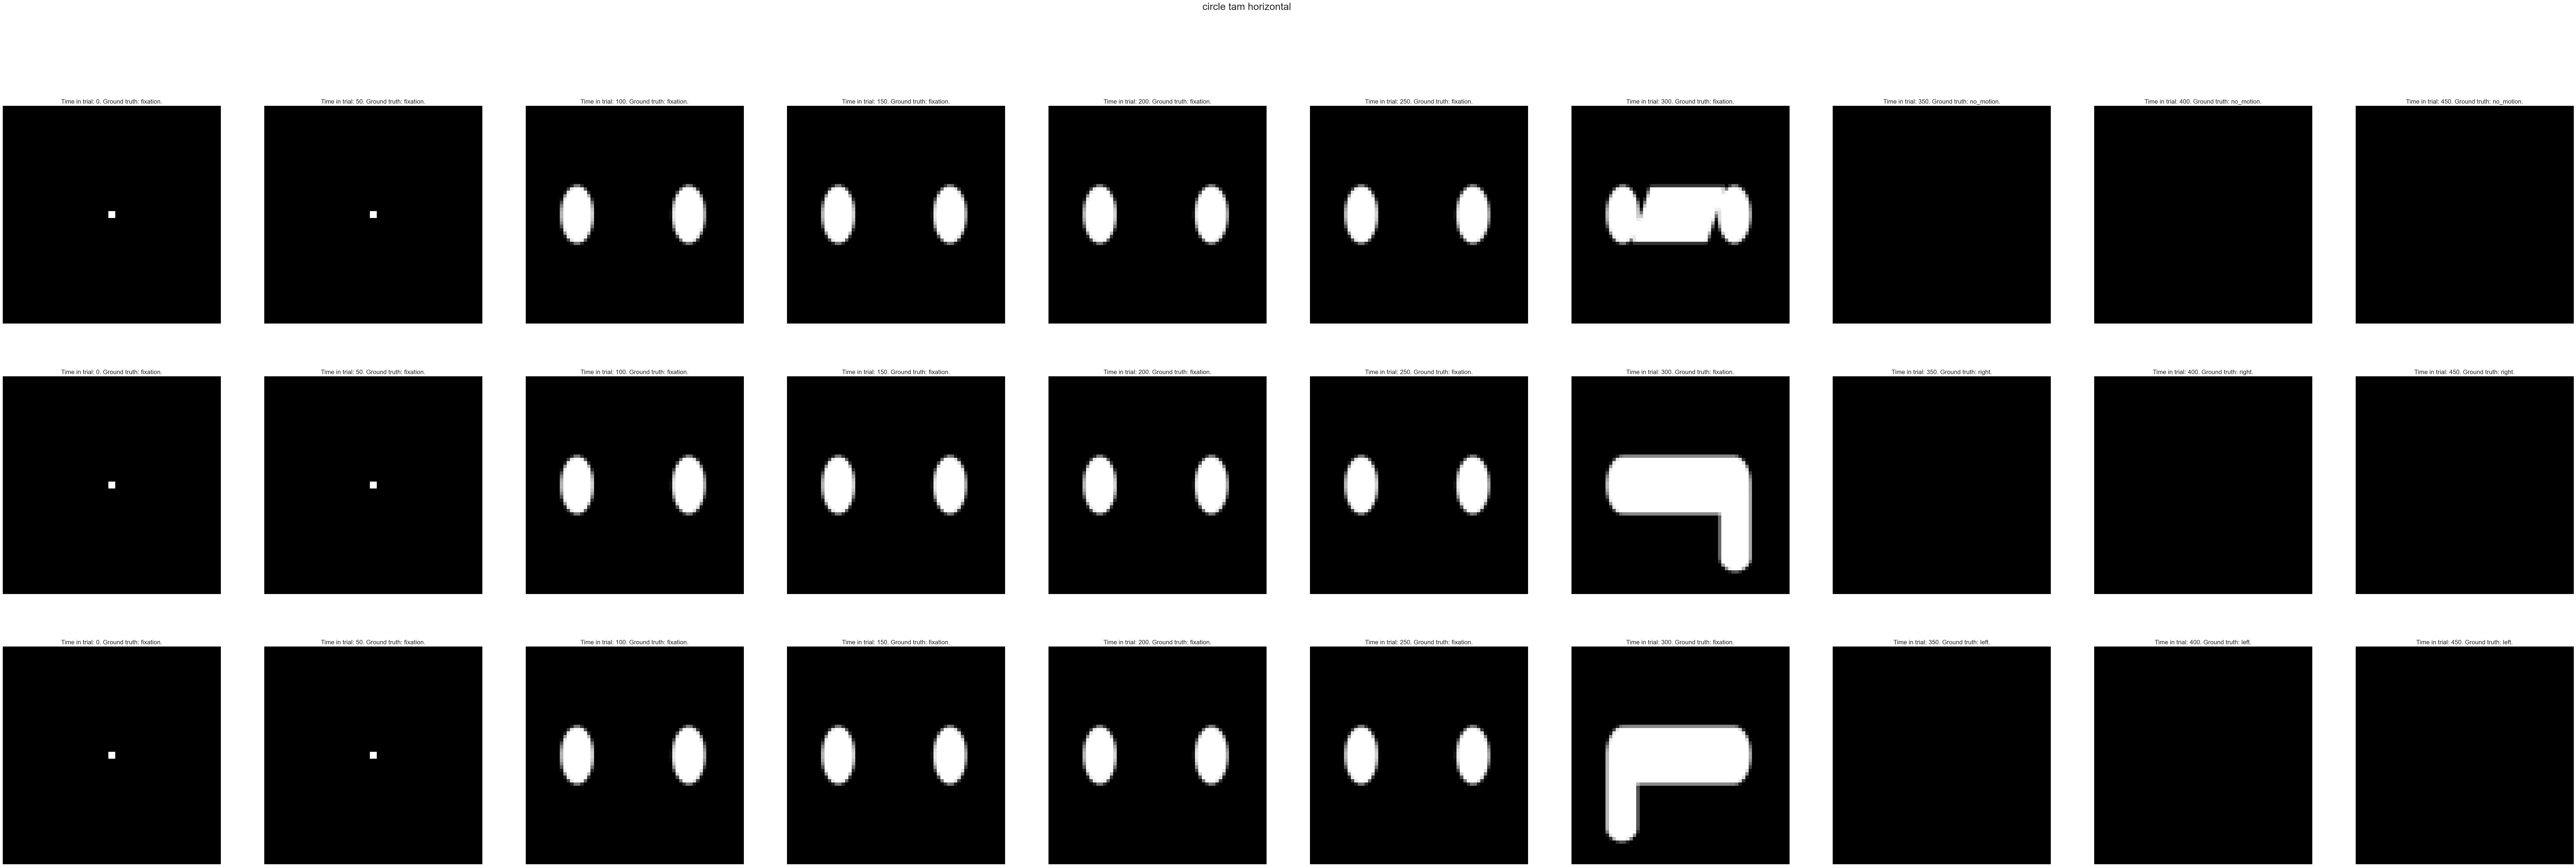

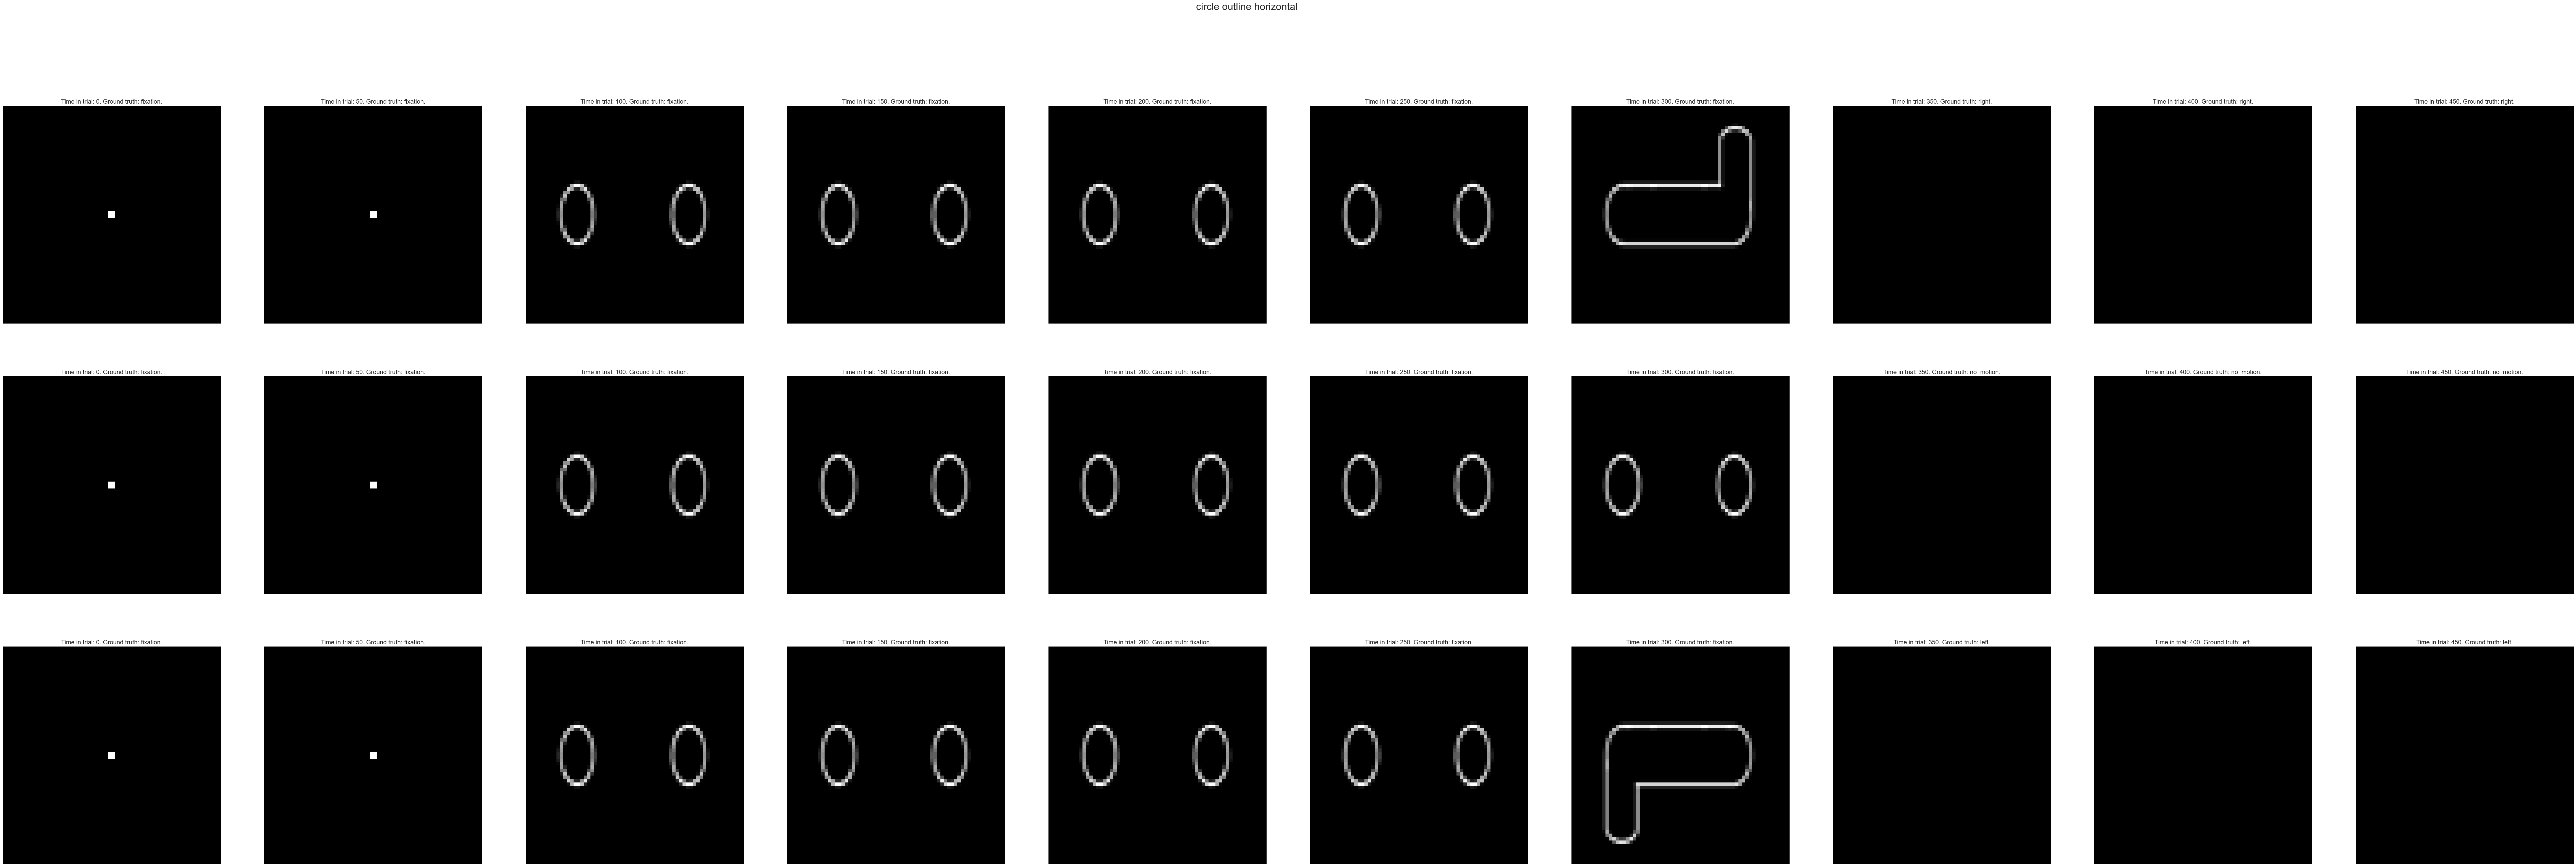

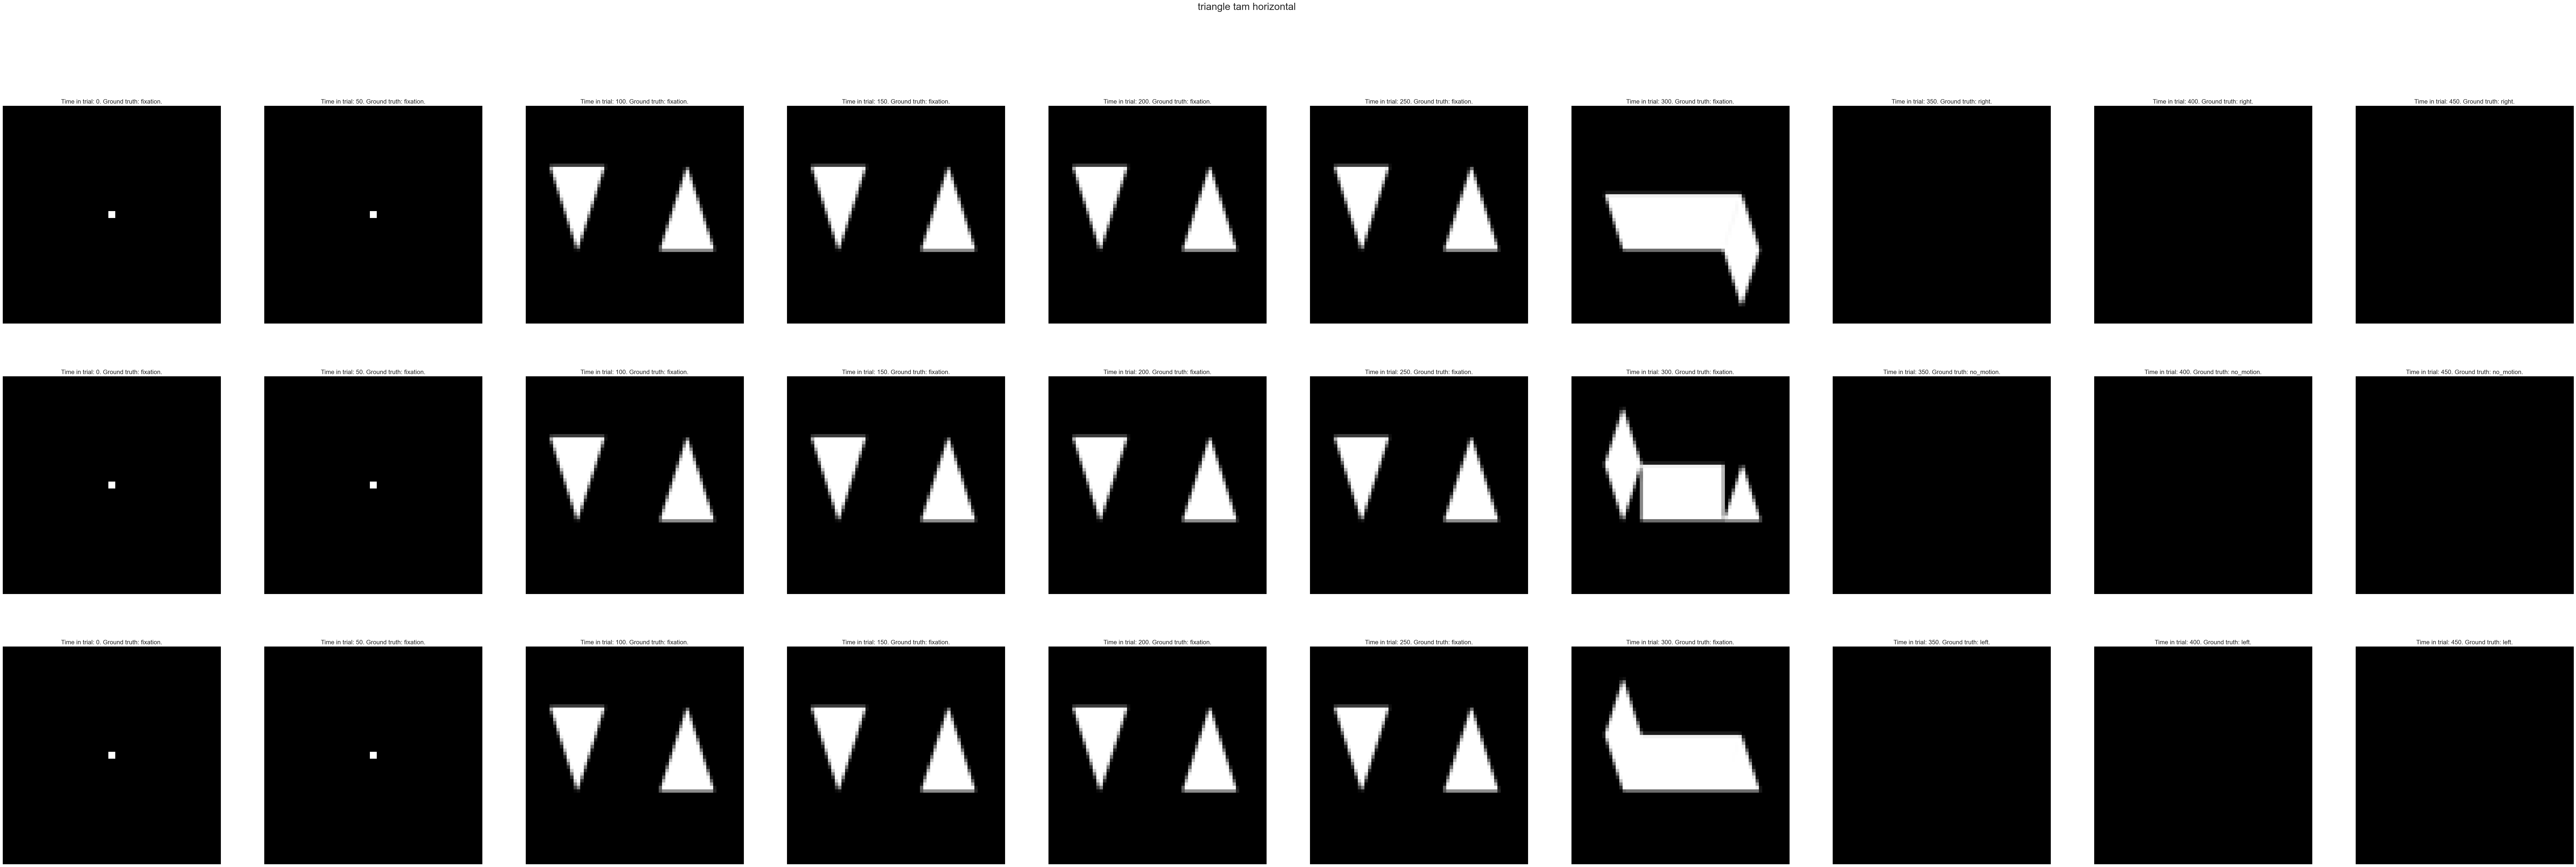

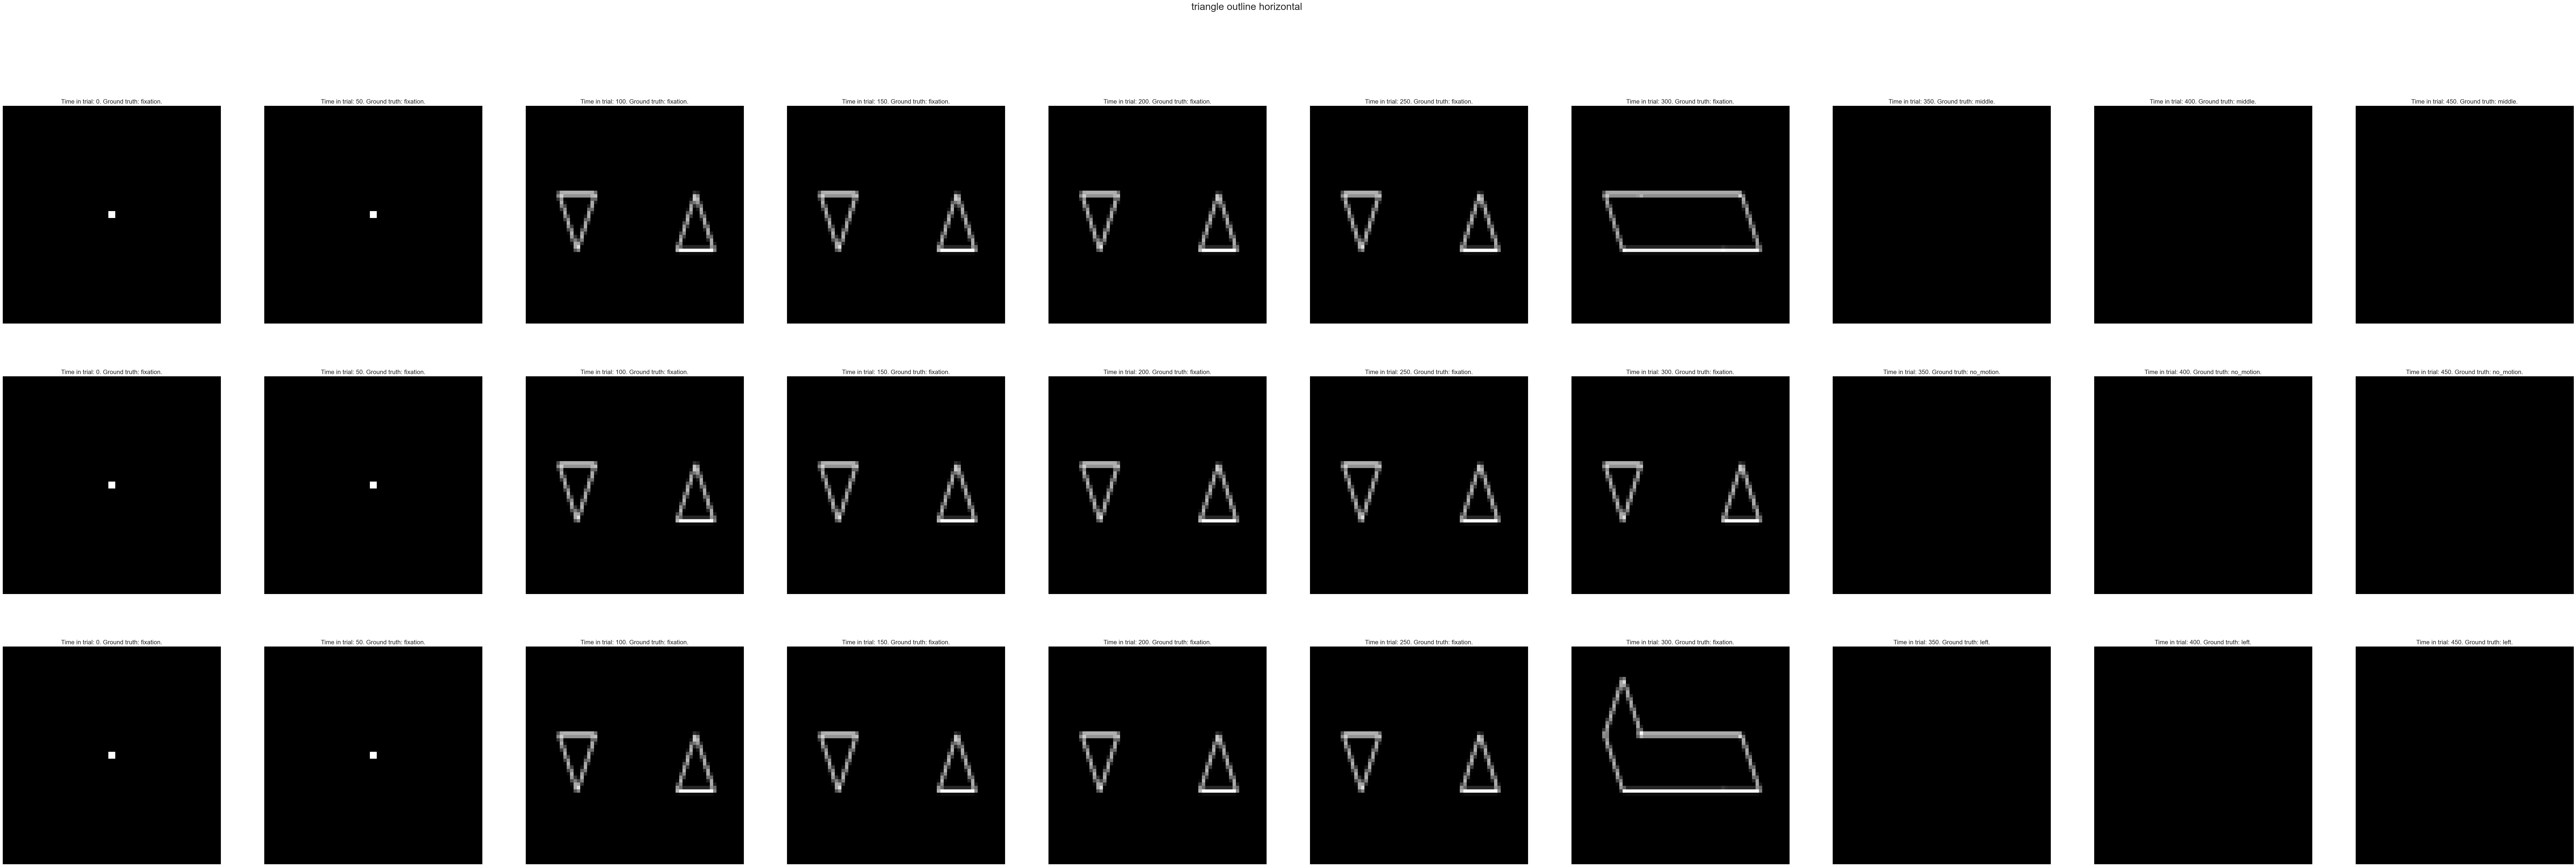

In [16]:
for dataset in tam_test_datasets.values():
    plot_dataset(n_trials=3, dataset=dataset, save_dir=FIG_DIR)